In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.data_loader import load_raw_data, build_dataset

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 50)

print("All imports OK")

All imports OK


In [3]:
data = load_raw_data()
df = build_dataset(data)
df.head(5)

circuits                       77 rows   9 cols
constructors                  212 rows   5 cols
constructor_standings      13,391 rows   7 cols
driver_standings           34,863 rows   7 cols
drivers                       861 rows   9 cols
lap_times                 589,081 rows   6 cols
pit_stops                  11,371 rows   7 cols
qualifying                 10,494 rows   9 cols
races                       1,125 rows  18 cols
results                    26,759 rows  18 cols
status                        139 rows   2 cols

  All files loaded successfully.

--- Building merged dataset ---

  After core merge:        (26759, 38)
  After standings merge:   (26759, 44)
  After qualifying merge:  (26759, 47)
  After pit stops merge:   (26759, 48)
  Final shape:    (26759, 48)
  Years:          1950 – 2024
  Unique races:   1,125
  Unique drivers: 861
  Podium rate:    12.7%
  DNF rate:       43.9%
  Points rate:    30.5%
  Saved → data/f1_merged.csv



,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,name,date,circuitRef,country,lat,lng,alt,driverRef,dob,nationality_driver,constructorRef,nationality_constructor,status,driver_age,is_dnf,podium,in_points,driver_standing_pts,driver_standing_pos,driver_wins_so_far,constructor_standing_pts,constructor_standing_pos,constructor_wins_so_far,quali_position,best_quali_sec,quali_gap_to_pole,pit_stop_count
0,20025,833,642,51,2.0,1,1.0,1,1,9.0,70,2:13:23.6,8003600.0,NaN,NaN,NaN,NaN,1,1950,1,9,British Grand Prix,1950-05-13,silverstone,UK,52.0786,-1.01694,153,farina,1906-10-30,Italian,alfa,Swiss,Finished,43.5,0,1,1,9.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,20026,833,786,51,3.0,2,2.0,2,2,6.0,70,+2.6,8006200.0,NaN,NaN,NaN,NaN,1,1950,1,9,British Grand Prix,1950-05-13,silverstone,UK,52.0786,-1.01694,153,fagioli,1898-06-09,Italian,alfa,Swiss,Finished,51.9,0,1,1,6.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2,20027,833,686,51,4.0,4,3.0,3,3,4.0,70,+52.0,8055600.0,NaN,NaN,NaN,NaN,1,1950,1,9,British Grand Prix,1950-05-13,silverstone,UK,52.0786,-1.01694,153,reg_parnell,1911-07-02,British,alfa,Swiss,Finished,38.9,0,1,1,4.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,20028,833,704,154,14.0,6,4.0,4,4,3.0,68,NaN,NaN,NaN,NaN,NaN,NaN,12,1950,1,9,British Grand Prix,1950-05-13,silverstone,UK,52.0786,-1.01694,153,cabantous,1904-10-08,French,lago,French,+2 Laps,45.6,0,0,1,3.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0
4,20029,833,627,154,15.0,9,5.0,5,5,2.0,68,NaN,NaN,NaN,NaN,NaN,NaN,12,1950,1,9,British Grand Prix,1950-05-13,silverstone,UK,52.0786,-1.01694,153,rosier,1905-11-05,French,lago,French,+2 Laps,44.5,0,0,1,2.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
print(f"Shape: {df.shape}\n")
print(f"Missing values (% per column):")
print("-" * 40)
missing = df.isnull().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]
for col, pct in missing.items():
    print(f"  {col:<35} {pct:.1f}%")

Shape: (26759, 48)

Missing values (% per column):
----------------------------------------
  time                                71.3%
  milliseconds                        71.3%
  fastestLapSpeed                     69.2%
  fastestLapTime                      69.2%
  fastestLap                          69.2%
  rank                                68.2%
  best_quali_sec                      61.4%
  quali_gap_to_pole                   61.4%
  quali_position                      60.8%
  position                            40.9%
  constructor_wins_so_far             7.0%
  constructor_standing_pos            7.0%
  constructor_standing_pts            7.0%
  driver_wins_so_far                  1.8%
  driver_standing_pos                 1.8%
  driver_standing_pts                 1.8%
  positionText                        0.7%
  number                              0.0%


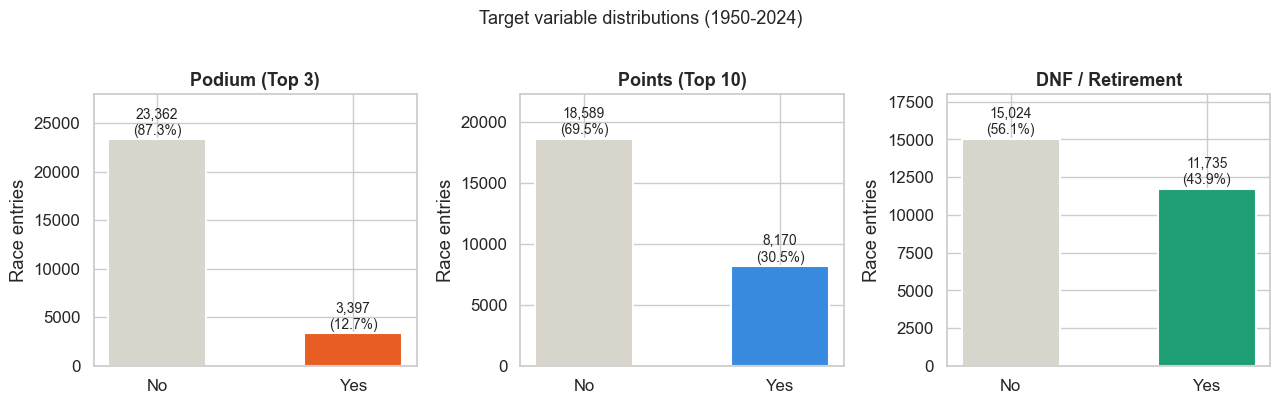

In [5]:
targets = {
    'podium':    ('Podium (Top 3)',   '#E85D24'),
    'in_points': ('Points (Top 10)',  '#378ADD'),
    'is_dnf':    ('DNF / Retirement', '#1D9E75'),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (col, (label, color)) in zip(axes, targets.items()):
    yes = df[col].sum()
    no  = len(df) - yes
    bars = ax.bar(['No', 'Yes'], [no, yes],
                  color=['#D8D6CC', color], width=0.5,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Race entries')
    for bar, val in zip(bars, [no, yes]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 150,
                f'{val:,}\n({val/len(df):.1%})',
                ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(no, yes) * 1.2)

plt.suptitle('Target variable distributions (1950-2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
grid_stats = (
    df[df['grid'].between(1, 20)]
    .groupby('grid')
    .agg(
        podium_rate=('podium', 'mean'),
        points_rate=('in_points', 'mean'),
    )
    .reset_index()
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        'Podium probability by grid position',
        'Points probability by grid position'
    ]
)

fig.add_trace(
    go.Bar(x=grid_stats['grid'], y=grid_stats['podium_rate'],
           marker_color='#E85D24', name='Podium rate',
           hovertemplate='Grid %{x}<br>Podium rate: %{y:.1%}'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=grid_stats['grid'], y=grid_stats['points_rate'],
           marker_color='#378ADD', name='Points rate',
           hovertemplate='Grid %{x}<br>Points rate: %{y:.1%}'),
    row=1, col=2
)

fig.update_yaxes(tickformat='.0%')
fig.update_xaxes(title_text='Grid position')
fig.update_layout(height=400, showlegend=False,
                  title_text='How much does grid position matter?')
fig.show()

print(f"\nGrid P1  podium rate: {grid_stats.loc[grid_stats['grid']==1,  'podium_rate'].values[0]:.1%}")
print(f"Grid P10 podium rate: {grid_stats.loc[grid_stats['grid']==10, 'podium_rate'].values[0]:.1%}")
print(f"Grid P20 podium rate: {grid_stats.loc[grid_stats['grid']==20, 'podium_rate'].values[0]:.1%}")


Grid P1  podium rate: 63.5%
Grid P10 podium rate: 5.8%
Grid P20 podium rate: 0.8%


In [7]:
top_drivers = (
    df.groupby('driverRef')['podium']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'podium': 'podiums'})
)

fig = px.bar(
    top_drivers, x='podiums', y='driverRef',
    orientation='h',
    title='Top 20 drivers — total podium finishes (1950-2024)',
    labels={'podiums': 'Podium count', 'driverRef': ''},
    color='podiums', color_continuous_scale='Oranges',
    text='podiums'
)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'},
                  coloraxis_showscale=False, height=550)
fig.show()

In [8]:
top_teams = (
    df[df['positionOrder'] == 1]
    .groupby('constructorRef')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='wins')
)

fig = px.bar(
    top_teams, x='wins', y='constructorRef',
    orientation='h',
    title='Top 15 constructors — total race wins',
    labels={'wins': 'Race wins', 'constructorRef': ''},
    color='wins', color_continuous_scale='Blues',
    text='wins'
)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'},
                  coloraxis_showscale=False, height=460)
fig.show()

In [9]:
dnf_by_year = (
    df.groupby('year')['is_dnf']
    .mean()
    .reset_index()
    .rename(columns={'is_dnf': 'dnf_rate'})
)

fig = px.line(
    dnf_by_year, x='year', y='dnf_rate',
    title='DNF rate over time — F1 has become dramatically more reliable',
    labels={'year': 'Season', 'dnf_rate': 'DNF rate'},
    markers=True
)
fig.update_traces(line_color='#E85D24', line_width=2, marker_size=4)
fig.update_yaxes(tickformat='.0%')
fig.update_layout(height=380)
fig.show()

print(f"\n1950-1969 avg DNF rate: {df[df['year'] <= 1969]['is_dnf'].mean():.1%}")
print(f"2010-2024 avg DNF rate: {df[df['year'] >= 2010]['is_dnf'].mean():.1%}")


1950-1969 avg DNF rate: 55.9%
2010-2024 avg DNF rate: 18.0%


/var/folders/w7/_97xxd591fz9hc4m2q3ftsh40000gn/T/ipykernel_28439/796469845.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


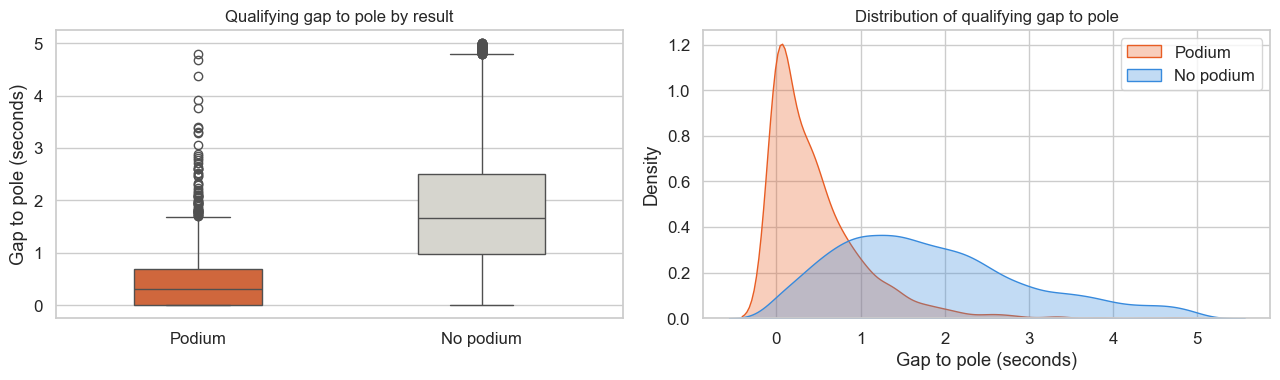


Avg gap — Podium:     0.474s
Avg gap — No podium:  1.837s


In [10]:
quali_df = df[
    df['quali_gap_to_pole'].notna() &
    df['quali_gap_to_pole'].between(0, 5)
].copy()
quali_df['Result'] = quali_df['podium'].map({1: 'Podium', 0: 'No podium'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=quali_df, x='Result', y='quali_gap_to_pole',
    palette={'Podium': '#E85D24', 'No podium': '#D8D6CC'},
    order=['Podium', 'No podium'],
    ax=axes[0], width=0.45
)
axes[0].set_title('Qualifying gap to pole by result', fontsize=12)
axes[0].set_ylabel('Gap to pole (seconds)')
axes[0].set_xlabel('')

for result, color in [('Podium', '#E85D24'), ('No podium', '#378ADD')]:
    subset = quali_df[quali_df['Result'] == result]['quali_gap_to_pole']
    sns.kdeplot(subset, ax=axes[1], label=result,
                color=color, fill=True, alpha=0.3)
axes[1].set_title('Distribution of qualifying gap to pole', fontsize=12)
axes[1].set_xlabel('Gap to pole (seconds)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAvg gap — Podium:     {quali_df[quali_df['podium']==1]['quali_gap_to_pole'].mean():.3f}s")
print(f"Avg gap — No podium:  {quali_df[quali_df['podium']==0]['quali_gap_to_pole'].mean():.3f}s")

In [11]:
standing_podium = (
    df[df['driver_standing_pos'].between(1, 15)]
    .groupby('driver_standing_pos')['podium']
    .mean()
    .reset_index()
    .rename(columns={'driver_standing_pos': 'Standing', 'podium': 'Podium rate'})
)

fig = px.bar(
    standing_podium, x='Standing', y='Podium rate',
    title='Driver championship standing vs podium rate',
    labels={'Standing': 'Driver standing before race', 'Podium rate': 'Podium rate'},
    color='Podium rate', color_continuous_scale='RdYlGn',
    text=standing_podium['Podium rate'].map('{:.1%}'.format)
)
fig.update_traces(textposition='outside')
fig.update_yaxes(tickformat='.0%')
fig.update_layout(coloraxis_showscale=False, height=400)
fig.show()

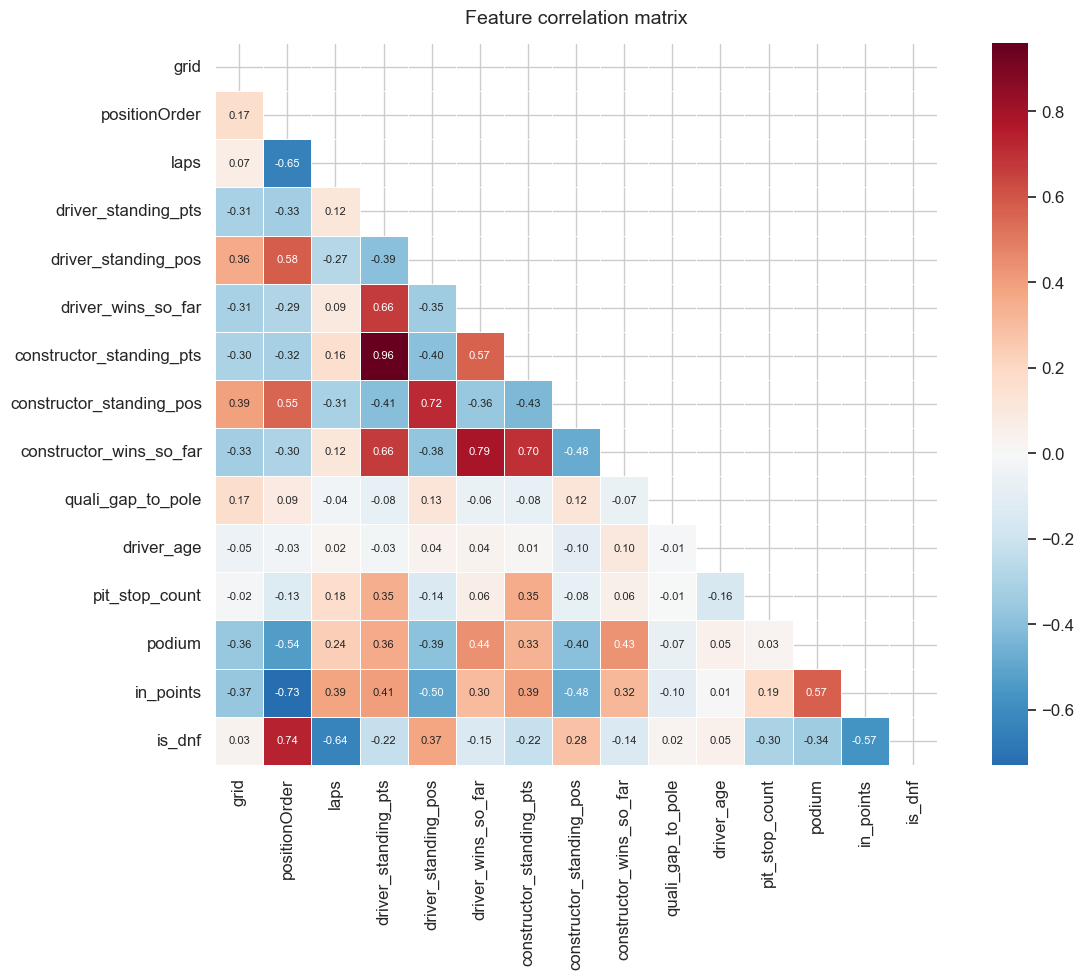

In [12]:
numeric_cols = [
    'grid', 'positionOrder', 'laps',
    'driver_standing_pts', 'driver_standing_pos', 'driver_wins_so_far',
    'constructor_standing_pts', 'constructor_standing_pos', 'constructor_wins_so_far',
    'quali_gap_to_pole', 'driver_age', 'pit_stop_count',
    'podium', 'in_points', 'is_dnf'
]

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    linewidths=0.4, annot_kws={'size': 8},
    square=True
)
ax.set_title('Feature correlation matrix', fontsize=14, pad=14)
plt.tight_layout()
plt.show()